In [1]:
import numpy as np
import math
from sympy import *
from scipy import integrate
import matplotlib.pyplot as plt
import random
import time

In [2]:
def TDT(T):
    b = T[0]+T[2]+2*T[3]; c = T[1]+T[2]+2*T[4]
    if b+c == 0:
        return 0
    else:
        return ((b-c)**2)/(b+c)

In [3]:
def EDOLS_TDT(x,n,m): #Enhanced DOLS
    TG = np.zeros((m,6))
    for i in range(m):
        for j in range(n):
            TG[i][int(x[j][i])] += 1
    
    #Step 1
    c = np.zeros((m,n,2))
    for i in range(m):
        T = TG[i]; X = TDT(T)
        for j in range(n):
            if x[j][i] == 0:
                Y = TDT([T[0]-1, T[1]+1, T[2], T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0]-1, T[1], T[2]+1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0]-1, T[1], T[2], T[3]+1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0]-1, T[1], T[2], T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0]-1, T[1], T[2], T[3], T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 1:
                Y = TDT([T[0]+1, T[1]-1, T[2], T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]-1, T[2]+1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]-1, T[2], T[3]+1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]-1, T[2], T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]-1, T[2], T[3], T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 2:
                Y = TDT([T[0]+1, T[1], T[2]-1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]+1, T[2]-1, T[3], T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]-1, T[3]+1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]-1, T[3], T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]-1, T[3], T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 3:
                Y = TDT([T[0]+1, T[1], T[2], T[3]-1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]+1, T[2], T[3]-1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]+1, T[3]-1, T[4], T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3]-1, T[4]+1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3]-1, T[4], T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if x[j][i] == 4:
                Y = TDT([T[0]+1, T[1], T[2], T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]+1, T[2], T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]+1, T[3], T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3]+1, T[4]-1, T[5]])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3], T[4]-1, T[5]+1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
            if T[5] >= 1:
                Y = TDT([T[0]+1, T[1], T[2], T[3], T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1]+1, T[2], T[3], T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2]+1, T[3], T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3]+1, T[4], T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
                Y = TDT([T[0], T[1], T[2], T[3], T[4]+1, T[5]-1])
                c[i][j][0] = max(c[i][j][0], Y-X); c[i][j][1] = max(c[i][j][1], X-Y)
    
    #Step 2
    LSS = np.zeros(int(2**m)); LS_SIGN = np.zeros(m)
    for j in range(n):
        LSJ = np.zeros((m,int(2**m)))
        LSJ[0][0] = c[0][j][0]; LSJ[0][1] = c[0][j][1]
        for i in range(1,m):
            for k in range(2**i):
                LSJ[i][2*k+0] = LSJ[i-1][k] + c[i][j][0]
                LSJ[i][2*k+1] = LSJ[i-1][k] + c[i][j][1]
        for i in range(int(2**m)):
            if LSS[i] < LSJ[m-1][i]:
                LSS[i] = LSJ[m-1][i]
                for l in range(m):
                    LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    LS = 0
    for i in range(int(2**m)):
        if LS < LSS[i]:
            LS = LSS[i]
            for l in range(m):
                LS_SIGN[l] = int(i/(2**(m-1-l)))%2
    #print(LS_SIGN)
        
    #Step 3
    EDOLS = np.zeros((m,2)) #\hat{LS}^{i+-}
    
    for j in range(m):
        for i in range(int(2**m)):
            if int(i/(2**(m-1-j)))%2 == 0:
                EDOLS[j][0] = max(EDOLS[j][0], LSS[i])
            else:
                EDOLS[j][1] = max(EDOLS[j][1], LSS[i])
    #print(EDOLS[:,0], EDOLS[:,1])
    
    #Step 4
    for i in range(m):
        if LS_SIGN[i] == 0:
            d = 1
        else:
            d = 0
        EDOLS[i][d] = 0
        for j in range(n):
            for s in range(int(2**m)):
                if int(s/(2**(m-1-i)))%2 == d:
                    t = 0
                    for l in range(m):
                        if l != i and EDOLS[l][int(s/(2**(m-1-l)))%2] != 0:
                            t += c[l][j][int(s/(2**(m-1-l)))%2]/EDOLS[l][int(s/(2**(m-1-l)))%2]
                    if t != 1:
                        EDOLS[i][d] = max(EDOLS[i][d], c[i][j][d]/(1-t))
    #print(EDOLS)
    return EDOLS[:,0], EDOLS[:,1]

In [4]:
def EDOSS_TDT_test(n,m): #Enhanced DOSS #epsilon = 20*m
    GS = (8*(n-1)/n)*m
    while(1):
        x = np.zeros((n,m))
        for i in range(n):
            x[i] = [random.randrange(6) for j in range(m)]
        EDOLSP, EDOLSN = EDOLS_TDT(x,n,m)
        f = 0
        for i in range(m):
            if EDOLSP[i] == 0 or EDOLSN[i] == 0:
                f = 1
            elif (EDOLSP[i]/EDOLSN[i])*24 > math.exp(5) or (EDOLSN[i]/EDOLSP[i])*24 > math.exp(5): 
            # When k = 4 and 5, the added noise will be larger than the experimental results because S(x) will be larger than EDOLS(x).
            # However, we conducted the experiments with assuming S(x) = LS(x).
            # Even under this assumption, the amount of noise is smallest when k = 3; therefore, k = 3 would be the most advisable.
                f = 1
        if f == 0:
            return EDOLSP, EDOLSN

In [5]:
def h2(z,l):
    return np.sqrt(l)/(math.pi*(z**2+l))

def h3(z,l):
    return (3*np.sqrt(3)*(l**(2/3)))/(4*math.pi*(math.fabs(z)**3+l))

def h4(z,l):
    return (np.sqrt(2)*(l**(3/4)))/(math.pi*(z**4+l))

def h6(z,l):
    return (3*(l**(5/6)))/(2*math.pi*(z**6+l))

def cdf(x,h,l):
    g = lambda z: h(z,l)
    return integrate.quad(g,-oo,x)

def noise(h,l,d): # using inverse transform sampling
    r = np.random.rand()
    q = 1000; z = 10
    for i in range(-50,50):
        if math.fabs(r - cdf(i/5,h,l)[0]) > q:
            z = (i-1)/5
            break
        else:
            q = min(q, math.fabs(r - cdf(i/5,h,l)[0]))
    if d == 0:
        return math.fabs(z)
    elif d == 1:
        return -math.fabs(z)
    
def alpha(k,l,m): #epsilon = 20*m
    return ((l**(1/k))*(20*m))/(2*((k-1)**((k-1)/k)))

In [6]:
def accuracy(n,m,EDOSSP,EDOSSN): # epsilon = 20*m
    acc = np.zeros((6,4))
    l = [0.5,1,2,3,4,5]
    SS = np.zeros(m); d = np.zeros(m)
    
    for j in range(20):
        for i in range(6):
            for t in range(m):
                if random.random()<0.5:
                    d[t] = 0; SS[t] = EDOSSP[j][t]
                else:
                    d[t] = 1; SS[t] = EDOSSN[j][t]
                acc[i][0] += math.fabs((SS[t]/alpha(2,l[i],m))*noise(h2,l[i],d[t]))
                acc[i][1] += math.fabs((SS[t]/alpha(3,l[i],m))*noise(h3,l[i],d[t]))
                acc[i][2] += math.fabs((SS[t]/alpha(4,l[i],m))*noise(h4,l[i],d[t]))
                acc[i][3] += math.fabs((SS[t]/alpha(6,l[i],m))*noise(h6,l[i],d[t]))
    return acc/(m*20)

[[0.17928828 0.0781509  0.07211927 0.13290814]
 [0.11057563 0.06714284 0.08667151 0.12542718]
 [0.10220965 0.05505733 0.07656876 0.11631503]
 [0.11687362 0.06372111 0.10389416 0.08668221]
 [0.11719528 0.05388836 0.07803001 0.1252134 ]
 [0.09032189 0.06633626 0.09548467 0.11346086]]
[[0.15951064 0.09545335 0.09676699 0.11019077]
 [0.13605746 0.07430967 0.09353303 0.10262483]
 [0.11897785 0.07048952 0.07459206 0.12911128]
 [0.07236109 0.07863378 0.11239905 0.13111553]
 [0.12078455 0.07259878 0.08021937 0.10431975]
 [0.08629781 0.09947596 0.07924992 0.13636202]]
[[0.09602721 0.09738071 0.08011904 0.17406862]
 [0.07202655 0.06307832 0.10068735 0.13740156]
 [0.12058099 0.06497198 0.07840351 0.12972378]
 [0.09407191 0.08291877 0.08740799 0.09630475]
 [0.10553153 0.07171017 0.08337437 0.11181928]
 [0.11221569 0.1093937  0.08191219 0.11719755]]
[[0.14872478 0.04927655 0.07064201 0.11699466]
 [0.09242964 0.08120888 0.09936831 0.11608595]
 [0.14702923 0.07647337 0.0852706  0.13202159]
 [0.125282

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


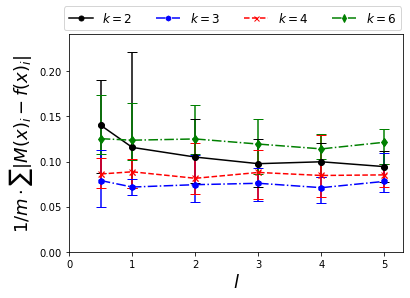

In [7]:
n = 150; m = 2

acc = np.zeros((6,4))
max_acc = np.zeros((6,4)); min_acc = np.ones((6,4))
sum_acc = np.zeros((6,4))

EDOSSP = np.zeros((20,m)); EDOSSN = np.zeros((20,m))
for i in range(20):
    EDOSSP[i], EDOSSN[i] = EDOSS_TDT_test(n,m)

jj = 10
for j in range(jj):
    acc = accuracy(n,m,EDOSSP,EDOSSN)
    for i in range(6):
        for k in range(4):
            max_acc[i][k] = max(max_acc[i][k], acc[i][k])
            min_acc[i][k] = min(min_acc[i][k], acc[i][k])
            sum_acc[i][k] += acc[i][k]
    print(acc)
acc = sum_acc/jj

y_err = np.zeros((2,6,4))
for k in range(4):
    y_err[0,:,k] = acc[:,k] - min_acc[:,k]
    y_err[1,:,k] = max_acc[:,k] - acc[:,k]

l = [0.5,1,2,3,4,5]

print(acc)
fig = plt.figure()
plt.ylim(0, max(max_acc[i][j] for i in range(6) for j in range(4))+0.02)
plt.xlim(-0.01, 5.3)
plt.errorbar(l, acc[:,0], yerr = y_err[:,:,0], capsize=5, fmt='o', ecolor='black', markeredgecolor = "black", color='black')
plt.plot(l, acc[:,0], marker="o", markersize=5, color = "black", linestyle = "-", label = "$k = 2$")
plt.errorbar(l, acc[:,1], yerr = y_err[:,:,1], capsize=5, fmt='h', ecolor='blue', markeredgecolor = "blue", color='blue')
plt.plot(l, acc[:,1], marker="h", markersize=5, color = "blue", linestyle = "dashdot", label = "$k = 3$")
plt.errorbar(l, acc[:,2], yerr = y_err[:,:,2], capsize=5, fmt='x', ecolor='red', markeredgecolor = "red", color='red')
plt.plot(l, acc[:,2], marker="x", markersize=5, color = "red", linestyle = "--", label = "$k = 4$")
plt.errorbar(l, acc[:,3], yerr = y_err[:,:,3], capsize=5, fmt='d', ecolor='green', markeredgecolor = "green", color='green')
plt.plot(l, acc[:,3], marker="d", markersize=5, color = "green", linestyle = "dashdot", label = "$k = 6$")
plt.legend(bbox_to_anchor=(0.49, 1.02), loc='lower center', borderaxespad=0, ncol=4, fontsize=12)
plt.xlabel("$l$", fontsize = 18)
plt.ylabel("$1/m \cdot \sum |M(x)_i - f(x)_i|$", fontsize = 18)
fig.savefig("Accuracy_TDT_kl_m=2.png")
fig.savefig("figs/Accuracy_TDT_kl_m=2.eps", bbox_inches="tight", pad_inches=0.05)